# Homework #5

## Ensemble learning

This colaboratory contains Homework #5 of the Machine Learning course, which is due **April 20, midnight (23:59 EEST time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

Pooh

##List of Homework's exercises:

1.   [Ex1](#scrollTo=ux5PBYkbwewj) - 3 points
2.   [Ex2](#scrollTo=Gezm0AO80ary) - 4 points
3.   [Ex3](#scrollTo=avCryKaDzJqn) - 3 points
4.   [Bonus 1](#scrollTo=jdZkblZW7bEp) - 2 points (based on quality of presentation)


In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# For plotting like a pro
!pip install -q plotnine
from plotnine import *

from sklearn.linear_model import LogisticRegression

In [2]:
def create_random_2c_data (D, N):
  """
  Function create_random_2c_data generates two sets of D dimensional
  points (N points each), one for each class. The first set is sampled from D
  dimensional Gaussian distribution with mean 0 and standard deviation 1. The
  second set is generated from the distribution, with mean 1 and standard
  deviation 1.
  """
  # Generating N points for the first class
  mu_vec1 = np.zeros(D) # creates a vector of zeros, these are averages across each dimension
  cov_mat1 = np.eye(D) # creates a diagonal matrix of size D x D, all values except diagonal are 0
  class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, N)

  # The same stuff as above, just averages are shifted into 1
  mu_vec2 = np.ones(D) # creates a vector of ones
  cov_mat2 = np.eye(D)
  class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, N)

  # a lot of boring things....
  # gluing together two matrices generated above
  data = pd.DataFrame(np.concatenate((class1_sample, class2_sample)))

  # Create names for columns
  data.columns = [ 'x' + str(i) for i in (np.arange(D)+1)]

  # Create a class column
  data['class'] = np.concatenate((np.repeat(0, N), np.repeat(1, N)))

  # This is important for plotting and modelling
  data['class'] = data['class'].astype('category')

  return data



---


## Homework exercise 1: implement and train a bagging classifier with 3 K-NN models as estimators (3 points)


<font color='red'> In this exercise you will need to use `classify_knn` function from the first practice session to train three different KNN models on three resamples of this dataset. </font>


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
np.random.seed(2342347823) # random seed, this number was random, no need to make conspiracies around it

D = 2 # two dimensions
N = 100 # points per class

whole_data = create_random_2c_data(D, N)

# Randomly splitting data into train (60%) and validation (40%)
train, val = train_test_split(whole_data, random_state = 111, test_size = 0.40)

n_bootstraps = 3
np.random.seed(1111)

# creating resamples
resamples = [resample(train, n_samples = int(len(train)), replace=True).index.values for i in range(n_bootstraps)]

# first resample
train_resample1 = train.loc[resamples[0]]

# second resample
train_resample2 = train.loc[resamples[1]]

# third resample
train_resample3 = train.loc[resamples[2]]

<font color='red'> Here, I just convert pandas DataFrame into Numpy arrays that are easier to use list comprehension mechanisms on. </font>

In [4]:
train1 = np.asarray(train_resample1[['x1','x2']])
labels1 = np.asarray(train_resample1[['class']]).reshape((train_resample1.shape[0]))

train2 = np.asarray(train_resample2[['x1','x2']])
labels2 = np.asarray(train_resample2[['class']]).reshape((train_resample2.shape[0]))

train3 = np.asarray(train_resample3[['x1','x2']])
labels3 = np.asarray(train_resample3[['class']]).reshape((train_resample3.shape[0]))

val_points = np.asarray(val[['x1','x2']])
val_labels = np.asarray(val[['class']]).reshape((val.shape[0]))

<font color='red'>  **(Homework exercise 1- a)** Copy and adapt `classify_knn` function from the first homework and practice session to operate on 2D points. **(1 point)**</font>

In [10]:
def dist(point1, point2): # function dist is also from the first practice session
  # sum of squared coordinate-wise differences under sqrt
  return(np.sqrt(np.sum((point2 - point1)**2)))

def classify_knn(val_point, k, train, labels):

  ##### YOUR CODE STARTS #####
  all_distances = [dist(val_point, train_point) for train_point in train]
  nearest_neighbours = labels[np.argsort(all_distances)[:k]]
  predicted_classes, counts = np.unique(nearest_neighbours, return_counts=True)
  prediction = predicted_classes[np.argmax(counts)]
  ##### YOUR CODE ENDS #####

  return prediction

<font color='red'> Test that the function was adapted correctly by running the following example </font>

In [11]:
val_point = val_points[1]
print(f'predicted class of the first point is {classify_knn(val_point, 5,  train1, labels1)}, while the true class is {val_labels[1]}')

predicted class of the first point is 0, while the true class is 0


<font color='red'> **(Homework exercise 1- b)** Classify each point from the validation set using `classify_knn` function. Use different resamples and list comprehension [(do something with point) for point in points]. Fix `k` at 5. **(1 point)**</font>


In [12]:
k = 5

# Use three K-NN models that work on three different resamples

##### YOUR CODE STARTS #####
val['knn1'] = [classify_knn(point, k, train1, labels1) for point in val_points]
val['knn2'] = [classify_knn(point, k, train2, labels2) for point in val_points]
val['knn3'] = [classify_knn(point, k, train3, labels3) for point in val_points]
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 1- c)** Aggregate individual predictions using the majority vote approach **(0.5 points)**</font>

In [13]:
##### YOUR CODE STARTS #####
val['knn_bagging'] = val[['knn1', 'knn2', 'knn3']].mode(axis=1)[0]
##### YOUR CODE ENDS #####

print(f"Accuracy of hand made bagged ensemble with 3 KNNs is {np.sum(val['knn_bagging'] == val['class'])/len(val[['class']])*100}%")

Accuracy of hand made bagged ensemble with 3 KNNs is 66.25%


<font color='red'> **(Homework exercise 1- d)** Use sklearn `BaggingClassifier` to implement analogous model that uses KNeighborsClassifier as an estimator (with k = 5). Don't forget to use a random state for reproducibility.

Assess its performance on the same validation set and display it. **(0.5 points)**</font>


In [15]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

##### YOUR CODE STARTS #####
knn = KNeighborsClassifier(n_neighbors=5)
knn_begger = BaggingClassifier(estimator=knn, n_estimators=3, random_state=111)
knn_begger.fit(train[['x1', 'x2']], train['class'])
##### YOUR CODE ENDS #####
print(f"Accuracy of sklearn bagging with {3} KNNs {knn_begger.score(val[['x1', 'x2']], val[['class']])*100}%")

Accuracy of sklearn bagging with 3 KNNs 73.75%


## Homework exercise 2: eXtreme Gradient Boosting (XGBoost) (4 points)

<font color='red'> Let's finally build for ourselves a new shiny XGBoost model, the most popular algorithm for Kaggle competitions. </font>

<font color='red'> First, we need to load data (we shall use MNIST data again). </font>

In [17]:
from keras.datasets import mnist
(images, labels) = mnist.load_data()[0]

# reshape into a matrix format
images = images.reshape(-1, 28*28)

# use fewer images for faster training
train_images = images[0:2000]
train_labels = labels[0:2000]

test_images = images[2000:3000]
test_labels = labels[2000:3000]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<font color='red'> **(Homework exercise 2- a)** Use the tutorial page (https://xgboost.readthedocs.io/en/latest/python/python_intro.html and https://www.kaggle.com/anktplwl91/mnist-xgboost) to fill in the gaps in the following code and traing the XGBoost model. **(1 point)** </font>

In [18]:
import xgboost as xgb

##### YOUR CODE STARTS #####

# XGBoosts wants data to be wrapped into special formats
dtrain = xgb.DMatrix(train_images, label=train_labels)
dtest = xgb.DMatrix(test_images, label=test_labels)

# most meaningful parameters
param_list = [("objective", "multi:softmax"), ("eval_metric", "merror"), ("num_class", 10)]

# Number of trees
n_rounds = 600

# if nothing seems to improve for 50 iterations - stop
early_stopping = 50

# train for training and test for ... validation!
eval_list = [(dtrain, 'train'), (dtest, 'test')]

# 1,2,3.. go!
bst = xgb.train(params=dict(param_list),
                dtrain=dtrain,
                num_boost_round=n_rounds,
                evals=eval_list,
                early_stopping_rounds=early_stopping)
##### YOUR CODE ENDS #####

[0]	train-merror:0.07800	test-merror:0.22400
[1]	train-merror:0.04100	test-merror:0.18100
[2]	train-merror:0.02750	test-merror:0.15700
[3]	train-merror:0.01300	test-merror:0.14700
[4]	train-merror:0.01050	test-merror:0.14200
[5]	train-merror:0.00850	test-merror:0.13200
[6]	train-merror:0.00600	test-merror:0.12700
[7]	train-merror:0.00400	test-merror:0.12500
[8]	train-merror:0.00350	test-merror:0.11900
[9]	train-merror:0.00150	test-merror:0.11900
[10]	train-merror:0.00000	test-merror:0.11300
[11]	train-merror:0.00000	test-merror:0.11100
[12]	train-merror:0.00000	test-merror:0.11000
[13]	train-merror:0.00000	test-merror:0.10400
[14]	train-merror:0.00000	test-merror:0.10400
[15]	train-merror:0.00000	test-merror:0.10300
[16]	train-merror:0.00000	test-merror:0.10200
[17]	train-merror:0.00000	test-merror:0.09900
[18]	train-merror:0.00000	test-merror:0.10000
[19]	train-merror:0.00000	test-merror:0.09900
[20]	train-merror:0.00000	test-merror:0.09700
[21]	train-merror:0.00000	test-merror:0.0940

<font color='red'> **(Homework exercise 2- b)** Use the same tutorial page (https://xgboost.readthedocs.io/en/latest/python/python_intro.html) to find out how to evaluate the model **(1 point)** </font>

In [19]:
##### YOUR CODE STARTS #####
predictions = bst.predict(dtest)
accuracy = (predictions == test_labels).sum() / len(test_labels)
print(f"XGBoost accuracy: {accuracy * 100:.2f}%")
##### YOUR CODE ENDS #####

XGBoost accuracy: 91.10%


<font color='red'> Are you impressed with XGBoost performance? </font>

<font color='red'> **(Homework exercise 2- c)** Train Adaptive Boosting, Gradient Boosting and a simple KNN model from sklearn (KNeighborsClassifier) on the same trainign data and evaluate on the same test data. For each model use the default hyperparameters (e.g. `n_estimators` or `n_neighbors`). If you do not want to use default parameters, you can use `cross_val_score` to pick the best values for the hyperparameters using training data. Compare the performance of these three models and XGBoost and draw conclusions in a separate text cell.  **(2 points)** </font>

In [21]:
# AdaBoostClassifier
%%time
##### YOUR CODE STARTS #####
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

ada = AdaBoostClassifier()
ada.fit(train_images, train_labels)
ada_preds = ada.predict(test_images)
ada_acc = accuracy_score(test_labels, ada_preds)
print(f"AdaBoost accuracy: {ada_acc * 100:.2f}%")
##### YOUR CODE ENDS #####

AdaBoost accuracy: 61.50%
CPU times: user 3.2 s, sys: 4.74 ms, total: 3.21 s
Wall time: 3.36 s


In [22]:
# GradientBoostingClassifier
%%time
# might take considerable time if trained with default number of n_estimators
##### YOUR CODE STARTS #####
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(train_images, train_labels)
gb_preds = gb.predict(test_images)
gb_acc = accuracy_score(test_labels, gb_preds)
print(f"Gradient Boosting accuracy: {gb_acc * 100:.2f}%")
##### YOUR CODE ENDS #####

Gradient Boosting accuracy: 89.30%
CPU times: user 2min 2s, sys: 121 ms, total: 2min 2s
Wall time: 2min 16s


In [23]:
# KNeighborsClassifier
%%time
##### YOUR CODE STARTS #####
knn = KNeighborsClassifier()
knn.fit(train_images, train_labels)
knn_preds = knn.predict(test_images)
knn_acc = accuracy_score(test_labels, knn_preds)
print(f"KNN accuracy: {knn_acc * 100:.2f}%")
##### YOUR CODE ENDS #####

KNN accuracy: 91.20%
CPU times: user 392 ms, sys: 23.9 ms, total: 416 ms
Wall time: 218 ms


<font color='red'> How these models compare with each other and to XGBoost? Can you try to elaborate on this difference? </font>

In [ ]:
# Write your comment here:

# XGBoost gave 91.10% accuracy and trained in ~3 seconds. No wonder it’s a Kaggle favorite.
# It works well here because it's based on gradient boosting but also includes regularization, and is highly optimized under the hood (C++ backend).

# KNN slightly outperformed XGBoost with 91.20%, which honestly surprised me.
# It doesn’t actually "learn" anything, it just stores the data and compares distances at prediction time.
# Works well on this small, clean dataset because similar digits cluster tightly in feature space.
# But it doesn’t scale well — inference is O(n), so it would choke on bigger datasets.

# Gradient Boosting got 89.30%, not bad, but training time was over 2 minutes.
# That’s because sklearn’s implementation is pure Python and doesn’t parallelize well.
# Also lacks many of the speed tricks that XGBoost uses like tree pruning or regularized boosting.

# AdaBoost struggled here with only 61.50% accuracy. That’s expected — it uses weak learners like decision stumps, which are just too simple for image data.
# It’s better for binary classification on tabular datasets with clean  features. Just isn’t the right tool for this kind of task.

## Homework exercise 3: implement blending approach (3 points)
<font color='red'> In this exercise you will practice using blending approach to meta-learning. </font>

<font color='red'> **(Homework exercise 3- a)** to implement blending we first need to create a separate validation set that would be independent from training and test data. Below, use images from 0 to 1500 as training data, images from 1500 to 2000 as validation and from 2000 to 3000 as a test set. **(0.5 points)** </font>

In [24]:
from keras.datasets import mnist
(images, labels) = mnist.load_data()[0]

# reshape into a matrix format
images = images.reshape(-1, 28*28)

##### YOUR CODE STARTS #####
train_images = images[0:1500]
train_labels = labels[0:1500]

val_images = images[1500:2000]
val_labels = labels[1500:2000]

test_images = images[2000:3000]
test_labels = labels[2000:3000]
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 3- b)** Train three models (decision tree, k nearest neighbors classifier, and the logistic regression) with default parameters on the train data. **(0.5 points)** </font>

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

##### YOUR CODE STARTS #####
model1 = DecisionTreeClassifier()
model2 = KNeighborsClassifier()
model3 = LogisticRegression(max_iter=1000)
##### YOUR CODE ENDS #####

np.random.seed(1111)
##### YOUR CODE STARTS #####
model1.fit(train_images, train_labels)
##### YOUR CODE ENDS #####

np.random.seed(1111)
##### YOUR CODE STARTS #####
model2.fit(train_images, train_labels)
##### YOUR CODE ENDS #####

np.random.seed(1111)
##### YOUR CODE STARTS #####
model3.fit(train_images, train_labels)
##### YOUR CODE ENDS #####

LogisticRegression(max_iter=1000)

<font color='red'> **(Homework exercise 3- c)** Create a training set for the meta-learner by concatenating the predictions made by individual models on validation images. Hint: use function `np.concatenate` and `predict_proba` as we did for stacking. **(0.5 points)** </font>

In [26]:
##### YOUR CODE STARTS #####
proba1 = model1.predict_proba(val_images)
proba2 = model2.predict_proba(val_images)
proba3 = model3.predict_proba(val_images)

train_blending = np.concatenate([proba1, proba2, proba3], axis=1)
##### YOUR CODE ENDS #####

train_blending_labels = val_labels
train_blending.shape # if all was done correctly this shape should be (500, 30)

(500, 30)

<font color='red'> **(Homework exercise 3- d)** Create a test set for the meta-learner by concatenating the predictions made by each model on test images. Use the same function as in the cell above. **(0.5 points)** </font>

In [27]:
##### YOUR CODE STARTS #####
proba1_test = model1.predict_proba(test_images)
proba2_test = model2.predict_proba(test_images)
proba3_test = model3.predict_proba(test_images)

test_blending = np.concatenate([proba1_test, proba2_test, proba3_test], axis=1)
##### YOUR CODE ENDS #####

test_blending.shape # if all was done correctly this shape should be (1000, 30)

(1000, 30)

<font color='red'> **(Homework exercise 3- e)** Use a new model (SVM) as a meta-learner and train it on the `train_blending` data. **(0.5 points)** </font>

In [28]:
from sklearn.svm import SVC
np.random.seed(1111)

##### YOUR CODE STARTS #####
blending_model = SVC()
blending_model.fit(train_blending, train_blending_labels)
##### YOUR CODE ENDS #####

SVC()

<font color='red'> **(Homework exercise 3- f)** Evaluate the performance of the blending ensemble on the test set and comment on the difference between blending and stacking (that we tried in the practice session). Which one would you prefer and why?  **(0.5 points)** </font>

In [29]:
##### YOUR CODE STARTS #####
blending_preds = blending_model.predict(test_blending)
blending_accuracy = accuracy_score(test_labels, blending_preds)
print(f"Blending ensemble accuracy: {blending_accuracy * 100:.2f}%")
##### YOUR CODE ENDS #####

Blending ensemble accuracy: 90.20%


In [ ]:
# What is your take on the difference between blending and stacking (from practice session)?
# Which one would you prefer and why?
# Comment here:

# Blending is easier and faster to implement, just split off a validation set and stack model predictions.
# But it’s a bit less efficient, since we "waste" part of the data (validation set isn’t used for training base models),
# and the meta-learner only sees predictions on that small part.

# Stacking, on the other hand, is more complex but more powerful, as it uses k-folds to train base models and
# collect out-of-fold predictions for the meta-learner. This way, it makes full use of the training data and is more robust.

# In my case, blending already gave 90.20% accuracy, which is solid. But I’d prefer stacking for more serious tasks
# or competitions, because it usually generalizes better, especially on small datasets or when models overfit easily.
# For quick experiments or prototyping — blending is good enough and much simpler to set up, I agree.

# Bonus exercises
*(NB, these are optional exercises!)*


## Bonus exercise 1 (2 bonus points):
<font color='red'> We have seen that in general increasing the number of estimators in an ensemble leads to better performance. In this exercise, you will experiment with the number of estimators in different ensemblers to explore **convergence behavior** and **overfitting**.  
You will compare the performance of **bagging of decision trees, random forests, extreme RF, boosting with decision trees and stacking different decision trees.**
</font>
<font color='red'>
* Use MNIST dataset
* train different ensembles with various number of decision trees (ranging from 1 to 2000. i.e. choose a small max_depth for speed)
* plot the **classification error** with the number of decision trees in each ensembler in the same plot.
* Compare the convergence behavior to other ensembles (e.g. RFs as base classifiers)
* Explain the behaviour that your observe.
</font>

<font color='red'>
As usual, technical depth and good presentation are the key to get bonus points.
</font>


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training ensembles with 1 estimators...
Training ensembles with 5 estimators...
Training ensembles with 10 estimators...
Training ensembles with 25 estimators...
Training ensembles with 50 estimators...
Training ensembles with 100 estimators...
Training ensembles with 200 estimators...
Training ensembles with 400 estimators...
Training ensembles with 800 estimators...
Training ensembles with 1200 estimators...


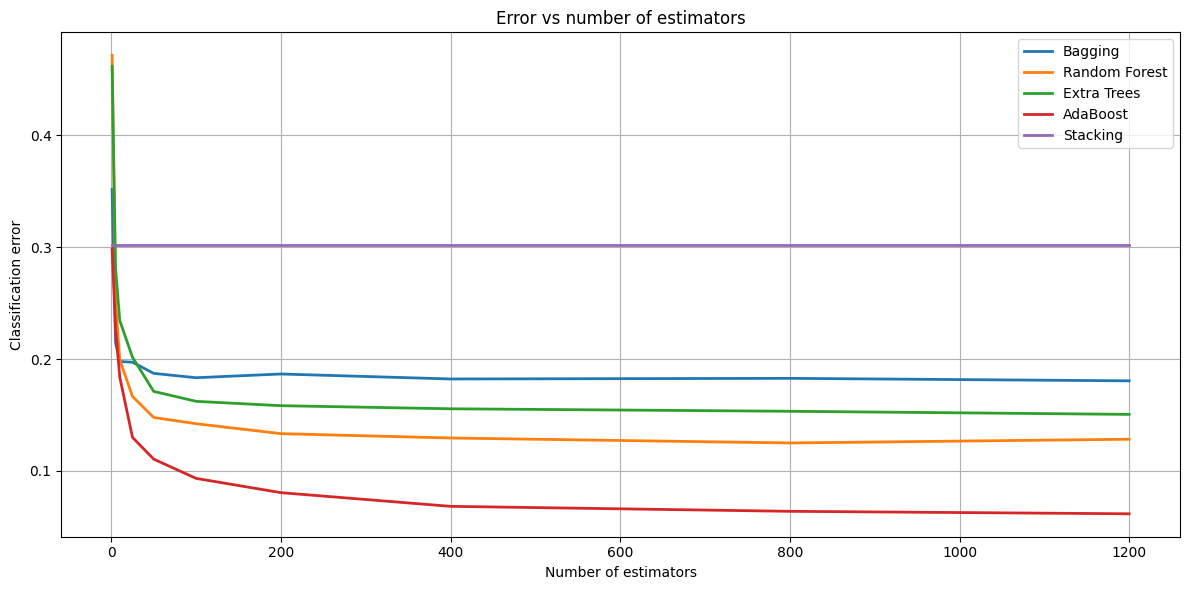

In [3]:
##### YOUR CODE STARTS #####
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier

# load and preprocess
(images, labels), _ = mnist.load_data()
X = images.reshape(-1, 28*28)
y = labels

# smaller subset for speed
X_train, X_test, y_train, y_test = train_test_split(X[:6000], y[:6000], test_size=0.3, random_state=42)

n_estimators_list = [1, 5, 10, 25, 50, 100, 200, 400, 800, 1200]

# shallow decision trees
base_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

errors = {
    'Bagging': [],
    'Random Forest': [],
    'Extra Trees': [],
    'AdaBoost': [],
    'Stacking': []
}

for n in n_estimators_list:
  print(f"Training ensembles with {n} estimators...")

  bagging = BaggingClassifier(estimator=base_tree, n_estimators=n, random_state=42)
  bagging.fit(X_train, y_train)
  bagging_pred = bagging.predict(X_test)
  errors['Bagging'].append(1 - accuracy_score(y_test, bagging_pred))

  rf = RandomForestClassifier(n_estimators=n, max_depth=5, random_state=42)
  rf.fit(X_train, y_train)
  rf_pred = rf.predict(X_test)
  errors['Random Forest'].append(1 - accuracy_score(y_test, rf_pred))

  et = ExtraTreesClassifier(n_estimators=n, max_depth=5, random_state=42)
  et.fit(X_train, y_train)
  et_pred = et.predict(X_test)
  errors['Extra Trees'].append(1 - accuracy_score(y_test, et_pred))

  ab = AdaBoostClassifier(estimator=base_tree, n_estimators=n, random_state=42)
  ab.fit(X_train, y_train)
  ab_pred = ab.predict(X_test)
  errors['AdaBoost'].append(1 - accuracy_score(y_test, ab_pred))

  if n == n_estimators_list[0]:
      stack = StackingClassifier(
          estimators=[
              ('tree1', DecisionTreeClassifier(max_depth=5, random_state=1)),
              ('tree2', DecisionTreeClassifier(max_depth=5, random_state=2)),
              ('tree3', DecisionTreeClassifier(max_depth=5, random_state=3))
          ],
          final_estimator=LogisticRegression(max_iter=1000)
      )
      stack.fit(X_train, y_train)
      stack_pred = stack.predict(X_test)
      errors['Stacking'] = [1 - accuracy_score(y_test, stack_pred)] * len(n_estimators_list)

plt.figure(figsize=(12, 6))
for model_name, model_errors in errors.items():
  plt.plot(n_estimators_list, model_errors, label=model_name, linewidth=2)

plt.xlabel("Number of estimators")
plt.ylabel("Classification error")
plt.title("Error vs number of estimators")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
##### YOUR CODE ENDS ##### (please do not delete this line)

**AdaBoost** was the fastest to improve. Even with as few as estimators (up to 50), its error rate dropped significantly. That’s because it keeps reweighting the training data to focus on the hardest examples, so it quickly reduces bias. Interestingly, even with 1000+ estimators, it didn’t show signs of overfitting likely because each shallow tree is weak on its own, so the ensemble stays balanced, I guess??

**Random Forests** also showed solid improvement early on. After about 400 trees, the performance flattened out, showing that we reached a point where more trees didn’t add much value, but also didn’t hurt. **Extra Trees** followed a similar curve but with slightly higher error across the board. The key difference is in how splits are made, because Extra Trees don’t search for the best threshold, they choose it randomly. This adds more bias but makes training faster.

Since **bagging** doesn’t touch the features or reweight the data (just bootstraps and averages), it mostly helps reduce variance. But with weak learners and no bias correction, it plateaued quickly, and adding more estimators beyond ~100 didn’t move the needle much.

Unlike the other methods, **stacking** didn’t benefit from scale here. Its line stayed completely flat. That’s because I kept it fixed at three base models without increasing the estimator count.

In short:
* AdaBoost succeeded in reducing bias
* Random Forests got a great balance between bias and variance
* Extra Trees were fast but less accurate
* Bagging had limited gains beyond the early stages
* Stacking needs more setup to show its strengths
* Adding more trees helped, especially early on, but after a certain point (near 200 estimators), most models converged and stopped improving

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the practice session, possibly answering the following questions:
* what would you suggest to add or remove?
* anything else you would like to tell us

In [ ]:
# Add your comments here:

# I’d suggest adding a more practical challenge — a complex dataset and a task that requires thoughtful model selection for stacking and boosting.
# It would be great to try advanced ensembles with proper cross-validation and calibration in a realistic scenario,
# where the choice of base learners actually matters.